In [51]:
import os
from os import listdir

from os.path import isfile, join, dirname, basename
import pandas as pd

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
import matplotlib.gridspec as gridspec

In [54]:
# from analysis_utils import collect_cv_metrics, map_groups, plot_cv_metrics

In [55]:
%run analysis_utils.py

In [56]:
# def collect_auprc_scores(metric='AUPRC', clf='avg', base_dir='results'):
#     all_results = []

#     for subdir in os.listdir(base_dir):
#         if subdir.startswith('__'):
#             print(f'skipping {subdir}')
#             continue
#         if subdir.startswith('luad1'):
#             print(f'skipping {subdir}')
#             continue
#         exp_path = os.path.join(base_dir, subdir)
#         file_path = os.path.join(exp_path, f'{metric}_{clf}.csv')
#         if os.path.isfile(file_path):
#             try:
#                 df = pd.read_csv(file_path)
#                 df['experiment_name'] = subdir  # Add experiment name
#                 all_results.append(df[['experiment_name', 'experiment', 'group', 'mean']])
#             except Exception as e:
#                 print(f"Failed to read {file_path}: {e}")

#     if not all_results:
#         raise ValueError(f"No valid {metric} files found.")

#     combined_df = pd.concat(all_results)
#     return combined_df


In [57]:
def process_and_sort(df):
    model_means = df.groupby('experiment')['mean'].mean().reset_index(name='mean_overall')
    # model_means = df.groupby('experiment')['mean'].median().reset_index(name='mean_overall')

    model_groups = df[['experiment', 'group']].drop_duplicates()

    sorted_models = model_means.merge(model_groups, on='experiment')
    sorted_models = sorted_models.sort_values(by=['group', 'mean_overall'], ascending=[True, False])
    sorted_model_order = sorted_models['experiment'].tolist()

    heatmap_df = df.pivot(index='experiment_name', columns='experiment', values='mean')
    heatmap_df = heatmap_df[sorted_model_order]

    return heatmap_df, sorted_models

In [58]:

def plot_composite_by_group_panels(heatmap_df, sorted_models, metric, clf='avg', save_dir='.'):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.gridspec as gridspec
    import numpy as np
    from os.path import join
    from matplotlib.cm import get_cmap
    from matplotlib.colors import Normalize

    sorted_models = sorted_models.round(2)
    heatmap_df = heatmap_df.round(2)

    # Calculate row-wise averages and sort
    row_avg = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.loc[row_avg.sort_values(ascending=False).index]

    grouped = sorted_models.groupby('group')
    n_groups = len(grouped)
    palette = sns.color_palette("husl", n_groups)
    color_map = dict(zip(grouped.groups.keys(), palette))

    global_vmin = heatmap_df.min().min()
    global_vmax = heatmap_df.max().max()
    norm = Normalize(vmin=global_vmin, vmax=global_vmax)
    cmap = get_cmap('viridis')

    total_models = sum(len(group_df) for _, group_df in grouped)
    fig = plt.figure(figsize=(max(6, total_models * 0.5 + 1.5), max(6, heatmap_df.shape[0] * 0.6)))

    group_model_counts = [len(group_df) for _, group_df in grouped]

    # gs = gridspec.GridSpec(
    #     3,
    #     n_groups + 2,
    #     width_ratios=group_model_counts + [0.2, 1.0],
    #     height_ratios=[1.2, 6, 0.4],
    #     hspace=0.3,
    #     wspace=0.1
    # )

    gs = gridspec.GridSpec(
        3,
        n_groups + 2,  # +2 for row avg and colorbar
        width_ratios=group_model_counts + [1.0, 0.2],  # row avg, colorbar
        height_ratios=[1.2, 6, 0.4],
        hspace=0.3,
        wspace=0.1
    )
        
    for i, (group_name, group_df) in enumerate(grouped):
        # cbar = (i == n_groups - 1)
        # cbar_ax = fig.add_subplot(gs[1, -2]) if cbar else None

        cbar = (i == n_groups - 1)
        cbar_ax = fig.add_subplot(gs[1, -1]) if cbar else None  # now last column
        
        color = color_map[group_name]
        model_names = group_df['experiment'].tolist()
        model_avg = group_df['mean_overall'].tolist()
        group_heatmap = heatmap_df[model_names]

        # Top bar plot
        ax_top = fig.add_subplot(gs[0, i])
        bars = ax_top.bar(range(len(model_avg)), model_avg, color=color)
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        # ax_top.set_title(f"{group_name}\nAvg {metric}", fontsize=6)
        ax_top.set_ylim(0.7, 1)

        # Remove all spines (bounding boxes)
        for spine in ax_top.spines.values():
            spine.set_visible(False)

        for idx, bar in enumerate(bars):
            height = bar.get_height()
            ax_top.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.2f}", ha='center', va='bottom', fontsize=6)

        # Heatmap
        ax_heatmap = fig.add_subplot(gs[1, i])
        sns.heatmap(
            group_heatmap,
            ax=ax_heatmap,
            annot=True,
            fmt=".2f",
            cmap='viridis',
            vmin=global_vmin,
            vmax=global_vmax,
            cbar=cbar,
            cbar_ax=cbar_ax,
            xticklabels=False,
            annot_kws={"size": 6}
        )
        ax_heatmap.set_xticklabels([])
        ax_heatmap.tick_params(axis='x', bottom=False)
        ax_heatmap.set_xlabel(group_name)
        if i != 0:
            ax_heatmap.set_ylabel("")
            ax_heatmap.set_yticks([])
            ax_heatmap.set_yticklabels([])

        xticklabels = model_names
        ax_heatmap.tick_params(axis='x', rotation=90, labelsize=8)
        ax_heatmap.set_ylabel('')

        # Bottom color bar
        ax_bottom = fig.add_subplot(gs[2, i])
        for j in range(len(model_names)):
            ax_bottom.add_patch(plt.Rectangle((j, 0), 1, 1, color=color))
            
        ax_bottom.set_xlim(0, len(model_names))
        ax_bottom.set_ylim(0, 1)
        ax_bottom.axis('off')
        for j, model in enumerate(model_names):
            ax_bottom.text(j + 0.5, -0.2, model, ha='right', va='top', rotation=90, fontsize=10, rotation_mode='anchor')

     # Right-side bar plot: row average
    # ax_right_bar = fig.add_subplot(gs[1, -1])
    # avg_vals = heatmap_df.mean(axis=1)
    # y_positions = np.arange(len(avg_vals))
    
    # Right-side bar plot: row average (now second-to-last column)
    ax_right_bar = fig.add_subplot(gs[1, -2])
    avg_vals = heatmap_df.mean(axis=1)
    y_positions = np.arange(len(avg_vals))
    colors = [cmap(norm(val)) for val in avg_vals]

    ax_right_bar.barh(y_positions, avg_vals.values, color=colors)

    ax_right_bar.invert_yaxis()  # Align with heatmap rows
    ax_right_bar.set_xlim(0.4, 1.0)
    ax_right_bar.set_yticks([])
    ax_right_bar.set_xticks([])
    ax_right_bar.set_xlabel(f"Avg {metric}", fontsize=5)

    for spine in ax_right_bar.spines.values():
        spine.set_visible(False)
        

    # Use heatmap order and colormap for coloring
    colors = [cmap(norm(val)) for val in avg_vals]

    bars = ax_right_bar.barh(y_positions, avg_vals.values, color=colors)
    
    if cbar_ax is not None:
        cbar_ax.tick_params(labelsize=6)  # Control colorbar tick font size here

    # Align and remove ticks
    # ax_right_bar.invert_yaxis()  # Align top-down with heatmap
    # ax_right_bar.set_xlim(0.7, 1.0)
    # ax_right_bar.set_yticks([])
    # ax_right_bar.set_xticks([])
    # ax_right_bar.set_xlabel(f"Avg {metric}", fontsize=8)

    # Remove border/spines
    for spine in ax_right_bar.spines.values():
        spine.set_visible(False)

    # Group legend (optional)
    fig.subplots_adjust(bottom=0.25)
    legend_handles = [plt.Line2D([0], [0], color=c, lw=10) for c in color_map.values()]
    # fig.legend(legend_handles, color_map.keys(), loc='lower center', ncol=n_groups)

    output_path = join(save_dir, f'{metric}_{clf}.png')
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Grouped panel heatmap saved to {output_path}")
    return fig

In [59]:
metrics= ['AUC', 'F1', 'AUPRC', 'Recall', 'Precision', 'Accuracy']

In [60]:
clfs = ['vote', 'mil', 'avg'] #['avg', 'mil']

In [61]:
# collect_auprc_scores

In [62]:
# group_map = {'geneformer':'Geneformer', 'baseline': 'Baseline', 'scgpt': 'scGPT'}
# 

In [63]:
# heatmap_df

In [64]:
# heatmap_df.to_csv('test.csv')

In [65]:
# metrics

In [66]:
# model_name_map

In [67]:
# test_df = collect_auprc_scores(metric='AUPRC',clf='avg', base_dir='./metrics')


In [68]:
test_df = pd.read_csv('results/classification_metrcis.csv')

In [69]:
test_df

,Unnamed: 0,AUC,AUPRC,Accuracy,F1,Precision,Recall,model,exp,strategy,group
0,0,0.952381,0.961735,0.769231,0.763636,0.833333,0.785714,geneformer_V1-10M-i2048_brca_pre_post,brca_pre_post_counts,vote,Geneformer
1,1,0.976190,0.976190,0.769231,0.769231,0.773810,0.773810,geneformer_V1-10M-i2048_brca_pre_post,brca_pre_post_counts,vote,Geneformer
2,2,0.861111,0.924242,0.666667,0.657143,0.687500,0.666667,geneformer_V1-10M-i2048_brca_pre_post,brca_pre_post_counts,vote,Geneformer
3,3,0.972222,0.976190,0.833333,0.833333,0.833333,0.833333,geneformer_V1-10M-i2048_brca_pre_post,brca_pre_post_counts,vote,Geneformer
4,4,0.888889,0.916667,0.750000,0.748252,0.757143,0.750000,geneformer_V1-10M-i2048_brca_pre_post,brca_pre_post_counts,vote,Geneformer
5,5,1.000000,1.000000,0.833333,0.828571,0.875000,0.833333,geneformer_V1-10M-i2048_brca_subtype,brca_subtype_counts,vote,Geneformer
6,6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,geneformer_V1-10M-i2048_brca_subtype,brca_subtype_counts,vote,Geneformer
7,7,0.777778,0.866667,0.666667,0.666667,0.666667,0.666667,geneformer_V1-10M-i2048_brca_subtype,brca_subtype_counts,vote,Geneformer
8,8,1.000000,1.000000,0.800000,0.800000,0.833333,0.833333,geneformer_V1-10M-i2048_brca_subtype,brca_subtype_counts,vote,Geneformer
9,9,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,geneformer_V1-10M-i2048_brca_subtype,brca_subtype_counts,vote,Geneformer


In [70]:
'experiment_name', 'experiment', 'group', 'mean'

('experiment_name', 'experiment', 'group', 'mean')

In [71]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]

In [72]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'avg']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp', 'group', 'model', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp'] 
dd['experiment'] = dd['model']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,geneformer_V1-10M-i2048_brca_pre_post,geneformer_V1-10M-i2048_brca_subtype,geneformer_V1-10M-i2048_brca_chemo
experiment_name,,,
brca_chemo_counts,NaN,NaN,0.656667
brca_pre_post_counts,0.907904,NaN,NaN
brca_subtype_counts,NaN,0.878889,NaN


In [73]:
# dd['experiment_name'] = dd['exp']
# dd['experiment'] = dd['exp']


/tmp/ipykernel_4803/3215541062.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUPRC_avg.png


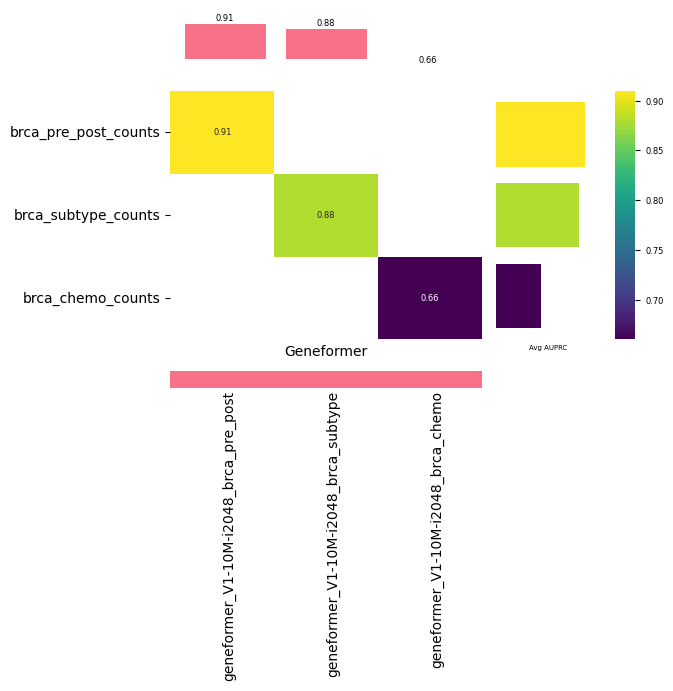

In [74]:
m = 'AUPRC'
clf = 'avg'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')

In [75]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'MIL']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp', 'group', 'model', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp'] 
dd['experiment'] = dd['model']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,geneformer_V1-10M-i2048_brca_subtype,geneformer_V1-10M-i2048_brca_pre_post,geneformer_V1-10M-i2048_brca_chemo
experiment_name,,,
brca_chemo_counts,NaN,NaN,0.603333
brca_pre_post_counts,NaN,0.907394,NaN
brca_subtype_counts,0.983333,NaN,NaN


/tmp/ipykernel_4803/3215541062.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUPRC_mil.png


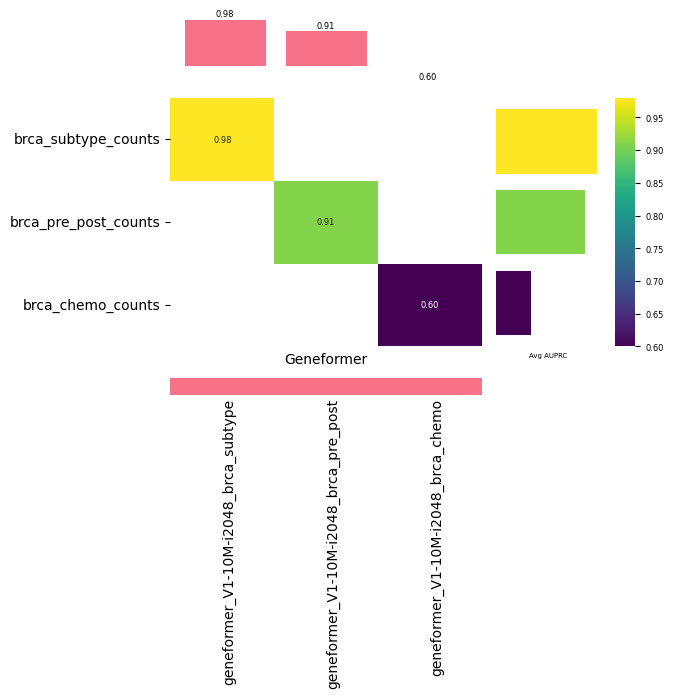

In [76]:
m = 'AUPRC'
clf = 'mil'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')

In [77]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'vote']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp', 'group', 'model', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp'] 
dd['experiment'] = dd['model']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,geneformer_V1-10M-i2048_brca_subtype,geneformer_V1-10M-i2048_brca_pre_post,geneformer_V1-10M-i2048_brca_chemo
experiment_name,,,
brca_chemo_counts,NaN,NaN,0.496667
brca_pre_post_counts,NaN,0.951005,NaN
brca_subtype_counts,0.973333,NaN,NaN


/tmp/ipykernel_4803/3215541062.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUPRC_vote.png


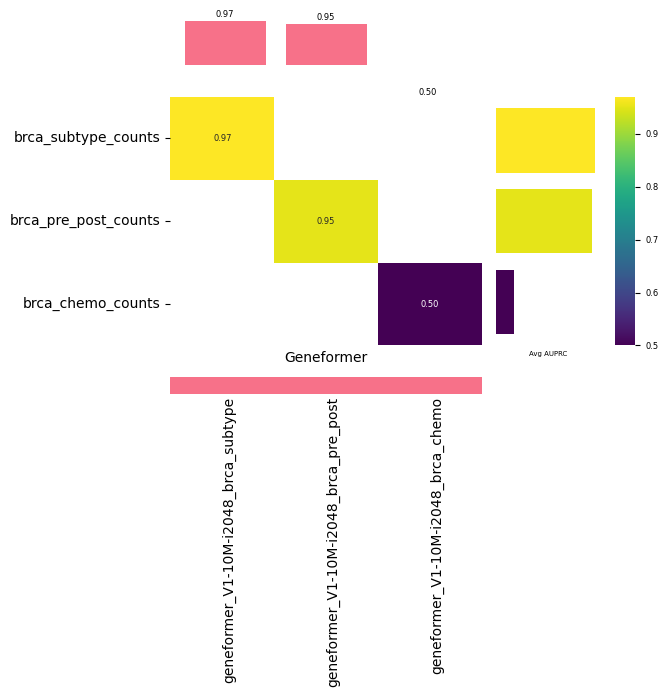

In [78]:
m = 'AUPRC'
clf = 'vote'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')

In [34]:
for clf in clfs:
    print(clf)
    for m in metrics:
        print(m)
        heatmap_df = collect_auprc_scores(metric=m,clf=clf, base_dir='./metrics')
        idx = heatmap_df.experiment.str.contains('continue')
        heatmap_df= heatmap_df[~idx]
        idx = heatmap_df.experiment.str.contains('freez')
        heatmap_df= heatmap_df[~idx]
        
        idx = heatmap_df.experiment.str.endswith('k')
        heatmap_df= heatmap_df[~idx]
        
        idx = heatmap_df.experiment.str.endswith('batch')
        heatmap_df= heatmap_df[~idx]
    
        idx = heatmap_df.experiment.str.endswith('_')
        heatmap_df= heatmap_df[~idx]
        
        idx = heatmap_df.experiment.str.endswith('all')
        heatmap_df= heatmap_df[~idx]
        
        # heatmap_df.group = heatmap_df.group.map(group_map)
        heatmap_df.experiment = heatmap_df.experiment.map(lambda x: model_name_map.get(x, x))
        heatmap_df.experiment_name = heatmap_df.experiment_name.map(experiment_name_map)
        # heatmap_df['experiment_name'] = heatmap_df.experiment
        heatmap_df_grouped, sorted_models = process_and_sort(heatmap_df)
        plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')
        

vote
AUC


NameError: name 'collect_auprc_scores' is not defined